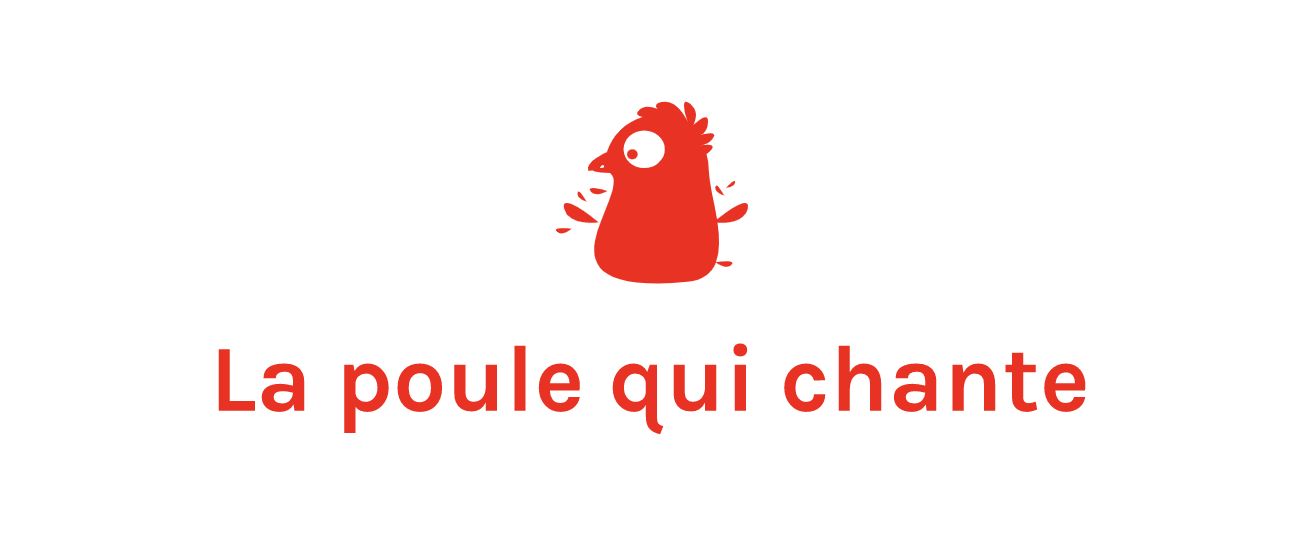

In [124]:
from IPython.display import Image, display

# Afficher l'image
display(Image(filename='C:/Users/Willkommen/OneDrive/Docs privés/HERVE/FORMATION/DATA_ANALYST_OC/PROJET 11/logo-la-poule-qui-chante.png'))


# Produire une étude de marché avec Python
## Partie 1 : Préparation des données

> &#9888; Ce *notebook* est le premier des deux *notebooks* qui vont composer notre étude de marché. Il contient la préparation, le nettoyage et l’analyse exploratoire des données.  

Nous travaillons chez La poule qui chante, une entreprise française d’agroalimentaire. Son activité principale est l’élevage et la vente de poulets sous le label “Poulet Agriculture Biologique”.  
Son activité actuelle est franco-française mais Patrick, le PDG de l’entreprise souhaite évaluer la possibilité de se développer à l'international. Pour l'instant, le champ des possibles est bien  
large : aucun pays particulier ni aucun continent n'est pour le moment choisi. Tous les pays sont envisageables !  

Notre objectif sera de proposer une analyse des groupements de pays que l’on peut cibler pour exporter nos poulets. Nous approfondirons ensuite l'étude de marché.  
L’idéal serait d’avoir au minimum 100 pays dans notre analyse (qui couvrent au moins 60% de la population mondiale).  

Les données qui vont être utilisées seront toutes issues des [statistiques de la *Food and Agriculture Organization of the United Nations (FAO)*](https://www.fao.org/faostat/fr/#home).
Nous disposons déjà de deux de leurs jeux de données.  
Nous avons récupéré d'autres données dont nous allons avoir besoin afin d'élargir les critères de l'analyse issues des [statistiques de la *Banque Mondiale*](https://donnees.banquemondiale.org/indicateur).  

Tous ces critères, que nous appellerons **indicateurs** dans la suite de cette étude, ont été choisis en nous inspirant de l'analyse PESTEL et avec pour objectif de pouvoir caractériser les pays.  
En voici la synthèse.

|Nom de variable               |Indicateur<sup>[1]</sup>                             |Information                                      |
|------------------------------|-----------------------------------------------------|-------------------------------------------------|
|`population_milliers_hab`     |Population en milliers d'habitants                   |Potentiel du marché                              |
|`consommation_volaille_pct`   |Ratio de consommation de volaille dans l'alimentation|Appétence des consommateurs pour la volaille     |
|`tdi_pct`                     |Taux de dépendance aux importations pour la volaille |Nécessité des pays à importer                    |
|`disponibilite_kg_p_an`       |Disponibilité de volaille par personne               |Volume de volaille alimentaire                   |
|`taux_de_croissance_pct`      |Taux de croissance du PIB                            |Dynamique économique du pays                     |
|`revenu_par_habitant_usd`     |Revenu par habitant en US$                           |Pouvoir d'achat des consommateurs                |
|`indice_stabilite_politique`  |Indice de stabilité politique                        |Facilité et risques liés aux échanges commerciaux|
|`indice_logistique`           |Indice de performance logistique                     |Qualité des infrastructures essentielles         |

*1. Les indicateurs sont donnés pour l'année 2022.*

In [125]:
# Importe les librairies
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import seaborn as sns

# Préparation des données pour l'analyse

Nous allons importer chacun des *datasets* nécessaires puis extraire, éventuellement calculer et compiler les indicateurs dans un *DataFrame* final. 

### Importation des *datasets*

In [126]:
# Importation des fichiers csv
df_disponibilite = pd.read_csv('C:/Users/Willkommen/OneDrive/Docs privés/HERVE/FORMATION/DATA_ANALYST_OC/PROJET 11/DATA/DisponibiliteAlimentaire_2022.csv', sep=";", encoding='utf-8')
df_macro = pd.read_csv('C:/Users/Willkommen/OneDrive/Docs privés/HERVE/FORMATION/DATA_ANALYST_OC/PROJET 11/DATA/PIB_Revenu_2022.csv', sep=";",encoding='utf-8')
df_stabilite = pd.read_csv('C:/Users/Willkommen/OneDrive/Docs privés/HERVE/FORMATION/DATA_ANALYST_OC/PROJET 11/DATA/Stabilite_politique_2022.csv', sep=";", encoding='utf-8')
df_population = pd.read_csv('C:/Users/Willkommen/OneDrive/Docs privés/HERVE/FORMATION/DATA_ANALYST_OC/PROJET 11/DATA/Population_2022.csv', sep=";", encoding='utf-8')
df_logistique = pd.read_csv('C:/Users/Willkommen/OneDrive/Docs privés/HERVE/FORMATION/DATA_ANALYST_OC/PROJET 11/DATA/IndiceLogistique_1960_2023.csv', sep=";", encoding='utf-8')

In [127]:
df_disponibilite.head(5)

,Code Domaine,Domaine,Code zone (ISO3),Zone,Code Élément,Élément,Code Produit (FBS),Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,FBS,Bilans Alimentaires (2010-),AFG,Afghanistan,5511,Production,S2511,Blé et produits,2022,2022,1000 t,3810.0,I,Valeur imputée,NaN
1,FBS,Bilans Alimentaires (2010-),AFG,Afghanistan,5611,Importations - quantité,S2511,Blé et produits,2022,2022,1000 t,3538.0,I,Valeur imputée,NaN
2,FBS,Bilans Alimentaires (2010-),AFG,Afghanistan,5072,Variation de stock,S2511,Blé et produits,2022,2022,1000 t,17.0,I,Valeur imputée,NaN
3,FBS,Bilans Alimentaires (2010-),AFG,Afghanistan,5911,Exportations - quantité,S2511,Blé et produits,2022,2022,1000 t,0.0,I,Valeur imputée,NaN
4,FBS,Bilans Alimentaires (2010-),AFG,Afghanistan,5301,Disponibilité intérieure,S2511,Blé et produits,2022,2022,1000 t,7331.0,I,Valeur imputée,NaN


In [128]:
df_disponibilite.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205313 entries, 0 to 205312
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Code Domaine            205313 non-null  object 
 1   Domaine                 205313 non-null  object 
 2   Code zone (ISO3)        205313 non-null  object 
 3   Zone                    205313 non-null  object 
 4   Code Élément            205313 non-null  int64  
 5   Élément                 205313 non-null  object 
 6   Code Produit (FBS)      205313 non-null  object 
 7   Produit                 205313 non-null  object 
 8   Code année              205313 non-null  int64  
 9   Année                   205313 non-null  int64  
 10  Unité                   205313 non-null  object 
 11  Valeur                  205313 non-null  float64
 12  Symbole                 205313 non-null  object 
 13  Description du Symbole  205313 non-null  object 
 14  Note                

In [129]:
df_macro.head(5)

,Code Domaine,Domaine,Code zone (ISO3),Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,MK,Indicateurs macro,AFG,Afghanistan,6119,Valeur US $ par habitant,22008,Produit Intérieur Brut,2022,2022,USD,344.649112,X,Ciffre de sources internationales,NaN
1,MK,Indicateurs macro,AFG,Afghanistan,6129,Croissance annuelle US$,22008,Produit Intérieur Brut,2022,2022,%,-6.503076,X,Ciffre de sources internationales,NaN
2,MK,Indicateurs macro,AFG,Afghanistan,6119,Valeur US $ par habitant,22011,Revenu national brut,2022,2022,USD,348.593157,X,Ciffre de sources internationales,NaN
3,MK,Indicateurs macro,AFG,Afghanistan,6129,Croissance annuelle US$,22011,Revenu national brut,2022,2022,%,-6.219944,X,Ciffre de sources internationales,NaN
4,MK,Indicateurs macro,ZAF,Afrique du Sud,6119,Valeur US $ par habitant,22008,Produit Intérieur Brut,2022,2022,USD,6766.481054,X,Ciffre de sources internationales,NaN


In [130]:
df_macro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844 entries, 0 to 843
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            844 non-null    object 
 1   Domaine                 844 non-null    object 
 2   Code zone (ISO3)        844 non-null    object 
 3   Zone                    844 non-null    object 
 4   Code Élément            844 non-null    int64  
 5   Élément                 844 non-null    object 
 6   Code Produit            844 non-null    int64  
 7   Produit                 844 non-null    object 
 8   Code année              844 non-null    int64  
 9   Année                   844 non-null    int64  
 10  Unité                   844 non-null    object 
 11  Valeur                  844 non-null    float64
 12  Symbole                 844 non-null    object 
 13  Description du Symbole  844 non-null    object 
 14  Note                    0 non-null      fl

In [131]:
df_stabilite.head(5)

,Code Domaine,Domaine,Code zone (ISO3),Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,FS,Données de la sécurité alimentaire,AFG,Afghanistan,6125,Valeur,21032,Stabilité politique et absence de violence/ter...,2022,2022,NaN,-2.55,X,Ciffre de sources internationales,NaN
1,FS,Données de la sécurité alimentaire,ZAF,Afrique du Sud,6125,Valeur,21032,Stabilité politique et absence de violence/ter...,2022,2022,NaN,-0.72,X,Ciffre de sources internationales,NaN
2,FS,Données de la sécurité alimentaire,ALB,Albanie,6125,Valeur,21032,Stabilité politique et absence de violence/ter...,2022,2022,NaN,0.11,X,Ciffre de sources internationales,NaN
3,FS,Données de la sécurité alimentaire,DZA,Algérie,6125,Valeur,21032,Stabilité politique et absence de violence/ter...,2022,2022,NaN,-0.74,X,Ciffre de sources internationales,NaN
4,FS,Données de la sécurité alimentaire,DEU,Allemagne,6125,Valeur,21032,Stabilité politique et absence de violence/ter...,2022,2022,NaN,0.61,X,Ciffre de sources internationales,NaN


In [132]:
df_stabilite.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            196 non-null    object 
 1   Domaine                 196 non-null    object 
 2   Code zone (ISO3)        196 non-null    object 
 3   Zone                    196 non-null    object 
 4   Code Élément            196 non-null    int64  
 5   Élément                 196 non-null    object 
 6   Code Produit            196 non-null    int64  
 7   Produit                 196 non-null    object 
 8   Code année              196 non-null    int64  
 9   Année                   196 non-null    int64  
 10  Unité                   0 non-null      float64
 11  Valeur                  196 non-null    float64
 12  Symbole                 196 non-null    object 
 13  Description du Symbole  196 non-null    object 
 14  Note                    0 non-null      fl

In [133]:
df_population.head(5)

,Code Domaine,Domaine,Code zone (ISO3),Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,OA,Séries temporelles annuelles,AFG,Afghanistan,511,Population totale,3010,Population-Estimations,2022,2022,1000 No,40578.842,X,Ciffre de sources internationales,NaN
1,OA,Séries temporelles annuelles,ZAF,Afrique du Sud,511,Population totale,3010,Population-Estimations,2022,2022,1000 No,62378.410,X,Ciffre de sources internationales,NaN
2,OA,Séries temporelles annuelles,ALB,Albanie,511,Population totale,3010,Population-Estimations,2022,2022,1000 No,2827.608,X,Ciffre de sources internationales,NaN
3,OA,Séries temporelles annuelles,DZA,Algérie,511,Population totale,3010,Population-Estimations,2022,2022,1000 No,45477.389,X,Ciffre de sources internationales,NaN
4,OA,Séries temporelles annuelles,DEU,Allemagne,511,Population totale,3010,Population-Estimations,2022,2022,1000 No,84086.227,X,Ciffre de sources internationales,NaN


In [134]:
df_population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            234 non-null    object 
 1   Domaine                 234 non-null    object 
 2   Code zone (ISO3)        234 non-null    object 
 3   Zone                    234 non-null    object 
 4   Code Élément            234 non-null    int64  
 5   Élément                 234 non-null    object 
 6   Code Produit            234 non-null    int64  
 7   Produit                 234 non-null    object 
 8   Code année              234 non-null    int64  
 9   Année                   234 non-null    int64  
 10  Unité                   234 non-null    object 
 11  Valeur                  234 non-null    float64
 12  Symbole                 234 non-null    object 
 13  Description du Symbole  234 non-null    object 
 14  Note                    0 non-null      fl

In [135]:
df_logistique.head(5)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,Indice de performance logistique : Qualité de ...,LP.LPI.INFR.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,AFE,Indice de performance logistique : Qualité de ...,LP.LPI.INFR.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,2.284842,NaN,2.392239,NaN,2.237778,NaN,NaN,NaN,2.518182,NaN
2,Afghanistan,AFG,Indice de performance logistique : Qualité de ...,LP.LPI.INFR.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,1.818951,NaN,1.835473,NaN,1.810000,NaN,NaN,NaN,1.700000,NaN
3,NaN,AFW,Indice de performance logistique : Qualité de ...,LP.LPI.INFR.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,2.252968,NaN,2.177056,NaN,2.172857,NaN,NaN,NaN,2.293333,NaN
4,Angola,AGO,Indice de performance logistique : Qualité de ...,LP.LPI.INFR.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,2.105263,NaN,2.133789,NaN,1.860000,NaN,NaN,NaN,2.100000,NaN


In [136]:
df_logistique.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 68 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    264 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            12 non-null     object 
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      flo

In [137]:
# Crée la liste des DataFrames
dfs = ['df_disponibilite', 'df_macro', 'df_population', 'df_stabilite', 'df_logistique']

# Affiche la taille des DataFrames
print(f'Dimensions des DataFrames :')
for df in dfs:
    print(f'- {df} : {eval(df).shape}')

del df

Dimensions des DataFrames :
- df_disponibilite : (205313, 15)
- df_macro : (844, 15)
- df_population : (234, 15)
- df_stabilite : (196, 15)
- df_logistique : (266, 68)


Les noms des variables comprennent des majuscules, des espaces ou des accents. Pour simplifier la lecture et les manipulations, nous créons une fonction qui va convertir les variables selon la convention *snake case*.

In [138]:
def snake_case (df):
    """Renomme les variables d'un DataFrame selon la convention snake case."""
    df.columns = (
        df.columns
        .str.lower()
        .str.replace('\'', '_')
        .str.replace(' - ', '_')
        .str.replace('-', '_')
        .str.replace(' ', '_')
        .str.normalize('NFKD')
        .str.encode('ascii', errors='ignore')
        .str.decode('utf-8')
    )

On applique ensuite cette fonction à nos jeux de données.

In [139]:
# Applique la fonction 'snake_case' aux DataFrames
for df in dfs:
    snake_case(eval(df))

del df

Nous renommons certaines colonnes de df_logistique pour avoir une uniformité avec les autres df.

In [140]:
df_logistique.rename(columns={'country_name' : 'zone', 'country_code' : 'code_zone_(iso3)'}, inplace=True)

# Création du DataFrame final

Avant de commencer à créer le DataFrame final, nous allons voir lequel contient le plus de pays.

In [141]:
# Affiche le nombre de pays de chaque DataFrame
print(f'Nombre de pays par DataFrame :')
for df in dfs:
    n_pays = eval(df)['zone'].nunique()
    print(f'- {df} : {n_pays}')

del df, n_pays

Nombre de pays par DataFrame :
- df_disponibilite : 189
- df_macro : 211
- df_population : 234
- df_stabilite : 196
- df_logistique : 259


C'est df_logistique qui contient le plus de pays. Nous allons donc reprendre les pays de ce DataFrame comme base de départ pour notre DataFrame final.  
Nous ajouterons ensuite les indicateurs choisis au fûr et à mesure.

### `df_logistique`

In [142]:
df_logistique.head(5)

,zone,code_zone_(iso3),indicator_name,indicator_code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,Indice de performance logistique : Qualité de ...,LP.LPI.INFR.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,AFE,Indice de performance logistique : Qualité de ...,LP.LPI.INFR.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,2.284842,NaN,2.392239,NaN,2.237778,NaN,NaN,NaN,2.518182,NaN
2,Afghanistan,AFG,Indice de performance logistique : Qualité de ...,LP.LPI.INFR.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,1.818951,NaN,1.835473,NaN,1.810000,NaN,NaN,NaN,1.700000,NaN
3,NaN,AFW,Indice de performance logistique : Qualité de ...,LP.LPI.INFR.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,2.252968,NaN,2.177056,NaN,2.172857,NaN,NaN,NaN,2.293333,NaN
4,Angola,AGO,Indice de performance logistique : Qualité de ...,LP.LPI.INFR.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,2.105263,NaN,2.133789,NaN,1.860000,NaN,NaN,NaN,2.100000,NaN


Ajout de zone et code_zone. Nous décidons également de ne conserver que le dernier indice_logistique connu.

In [143]:
# Crée le DataFrame final à partir de celui de la population
df_final = df_logistique.copy()

# Conserve que les variables utiles
df_final = df_final[['zone', 'code_zone_(iso3)','2022', '2018', '2016', '2014']]

# Création d'une nouvelle colonne pour les valeurs logistiques
df_final['indice_logistique_complet'] = (
    df_final['2022']  # Priorité 1 : Valeur de 2022
    .fillna(df_final['2018'])  # Priorité 2 : Valeur de 2018
    .fillna(df_final['2016'])  # Priorité 3 : Valeur de 2016
    .fillna(df_final['2014'])  # Priorité 4 : Valeur de 2014
)

# Renomme la variable 'indice_logistique_complet'
df_final = df_final.rename(
    columns={'indice_logistique_complet': 'indice_logistique'})

df_final.head(5)

,zone,code_zone_(iso3),2022,2018,2016,2014,indice_logistique
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN
1,NaN,AFE,2.518182,2.237778,2.392239,2.284842,2.518182
2,Afghanistan,AFG,1.700000,1.810000,1.835473,1.818951,1.700000
3,NaN,AFW,2.293333,2.172857,2.177056,2.252968,2.293333
4,Angola,AGO,2.100000,1.860000,2.133789,2.105263,2.100000


In [144]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   zone               264 non-null    object 
 1   code_zone_(iso3)   266 non-null    object 
 2   2022               177 non-null    float64
 3   2018               198 non-null    float64
 4   2016               199 non-null    float64
 5   2014               199 non-null    float64
 6   indice_logistique  207 non-null    float64
dtypes: float64(5), object(2)
memory usage: 14.7+ KB


Nous supprimons les colonnes inutiles pour la suite.

In [145]:
# Liste des colonnes à supprimer
colonnes_a_supprimer = ['2022', '2018', '2016', '2014']

# Suppression des colonnes spécifiées
df_final = df_final.drop(columns=colonnes_a_supprimer, errors='ignore')

# Affiche les premières lignes pour vérifier le résultat
print(df_final.head())

del colonnes_a_supprimer

          zone code_zone_(iso3)  indice_logistique
0        Aruba              ABW                NaN
1          NaN              AFE           2.518182
2  Afghanistan              AFG           1.700000
3          NaN              AFW           2.293333
4       Angola              AGO           2.100000


Nous constatons que 2 code_zone_(iso3) ne correspondent à aucun pays. Sur 266 pays, cela n'est pas signifiant.  
Nous décidons donc de supprimer ces 2 enregistrements.

In [146]:
# Suppression des enregistrements où 'code_zone_(iso3)' est nul ou incorrect
df_final = df_final[df_final['zone'].notna()]

# Vérifie la suppression
print(f"Nombre d'enregistrements après suppression : {len(df_final)}")
print(df_final.head())


Nombre d'enregistrements après suppression : 264
          zone code_zone_(iso3)  indice_logistique
0        Aruba              ABW                NaN
2  Afghanistan              AFG                1.7
4       Angola              AGO                2.1
5      Albanie              ALB                2.7
6      Andorre              AND                NaN


In [147]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 264 entries, 0 to 265
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   zone               264 non-null    object 
 1   code_zone_(iso3)   264 non-null    object 
 2   indice_logistique  205 non-null    float64
dtypes: float64(1), object(2)
memory usage: 8.2+ KB


Nous créons une liste de tous les pays avant suppression, qui nous permettra de voir quels auront été les pays supprimés.

In [148]:
# Crée une liste des pays avant suppression
pays_avant_suppression = set(df_final['zone'].unique())


Nous décidons d'effectuer une jointure avec le df_population pour avoir l'indice 'population_milliers_hab'

### `df_population`

In [149]:
# Jointure avec df_final sur 'code_zone_(iso3)'
df_final = df_final.merge(
    df_population[['code_zone_(iso3)', 'valeur']],
    on='code_zone_(iso3)',
    how='left'
)

# Renomme la variable 'valeur'
df_final = df_final.rename(
    columns={'valeur': 'population_milliers_hab'})

df_final.head(5)


,zone,code_zone_(iso3),indice_logistique,population_milliers_hab
0,Aruba,ABW,NaN,107.782
1,Afghanistan,AFG,1.7,40578.842
2,Angola,AGO,2.1,35635.029
3,Albanie,ALB,2.7,2827.608
4,Andorre,AND,NaN,79.705


Nous passons maintenant à l'indice 'consommation_volaille_pct' que nous trouvons dans le df_disponibilite.

### `df_disponibilite`

In [150]:
df_disponibilite.head(5)

,code_domaine,domaine,code_zone_(iso3),zone,code_element,element,code_produit_(fbs),produit,code_annee,annee,unite,valeur,symbole,description_du_symbole,note
0,FBS,Bilans Alimentaires (2010-),AFG,Afghanistan,5511,Production,S2511,Blé et produits,2022,2022,1000 t,3810.0,I,Valeur imputée,NaN
1,FBS,Bilans Alimentaires (2010-),AFG,Afghanistan,5611,Importations - quantité,S2511,Blé et produits,2022,2022,1000 t,3538.0,I,Valeur imputée,NaN
2,FBS,Bilans Alimentaires (2010-),AFG,Afghanistan,5072,Variation de stock,S2511,Blé et produits,2022,2022,1000 t,17.0,I,Valeur imputée,NaN
3,FBS,Bilans Alimentaires (2010-),AFG,Afghanistan,5911,Exportations - quantité,S2511,Blé et produits,2022,2022,1000 t,0.0,I,Valeur imputée,NaN
4,FBS,Bilans Alimentaires (2010-),AFG,Afghanistan,5301,Disponibilité intérieure,S2511,Blé et produits,2022,2022,1000 t,7331.0,I,Valeur imputée,NaN


Il faut tout d'abord connaître la valeur de 'produit' qui correspond à de la volaille.  
Nous décidons d'afficher toutes les valeurs uniques de la colonne 'produit'

In [151]:
# Affiche les valeurs uniques de la colonne 'produit'
valeurs_uniques_produit = df_disponibilite['produit'].unique()

# Affiche les valeurs uniques
print("Valeurs uniques dans la colonne 'produit' :")
print(valeurs_uniques_produit)


Valeurs uniques dans la colonne 'produit' :
['Blé et produits' 'Riz et produits' 'Orge et produits' 'Maïs et produits'
 'Seigle et produits' 'Avoine' 'Millet et produits' 'Sorgho et produits'
 'Céréales, autres' 'Manioc et produits' 'Pommes de Terre et produits'
 'Ignames' 'Racines nda' 'Sucre, canne' 'Sucre, betterave' 'Sucre Eq Brut'
 'Edulcorants Autres' 'Miel' 'Haricots' 'Pois'
 'Légumineuses Autres et produits' 'Noix et produits' 'Soja' 'Arachides'
 'Graines de tournesol' 'Graines Colza/Moutarde' 'Graines de coton'
 'Coco (Incl Coprah)' 'Sésame' 'Olives' 'Plantes Oleiferes, Autre'
 'Huile de Soja' "Huile d'Arachide" 'Huile de Tournesol'
 'Huile de Colza&Moutarde' 'Huile Graines de Coton' 'Huile de Palmistes'
 'Huile de Palme' 'Huile de Coco' 'Huile de Sésame' "Huile d'Olive"
 'Huile de Germe de Maïs' 'Huil Plantes Oleif Autr' 'Tomates et produits'
 'Oignons' 'Légumes, autres' 'Oranges, Mandarines'
 'Citrons & Limes et produits' 'Pamplemousse et produits'
 'Agrumes, Autres' 'Banane

Nous pouvons donc maintenant calculer cet indicateur et l'ajouter à df_final

In [152]:
# Crée un DataFrame temporaire en filtrant 'element'
df_temp = df_disponibilite.loc[df_disponibilite['element'] == 'Nourriture']

# Pivote 'produit'
df_temp = df_temp.pivot_table(
    index='code_zone_(iso3)', columns='produit', values='valeur'
).fillna(0)

# Calcul la part de consommation de volaille
df_temp['consommation_volaille_pct'] = (
    df_temp['Viande de Volailles'] / df_temp.sum(axis='columns') * 100
).round(2)

# Réinitialise l'index
df_temp = df_temp.reset_index().rename_axis(None, axis='columns')

# Ajoute la variable à 'df_final'
df_final = pd.merge(
    df_final,
    df_temp[['code_zone_(iso3)', 'consommation_volaille_pct']],
    how='left',
    on='code_zone_(iso3)'
)

del df_temp

df_final.head(3)

,zone,code_zone_(iso3),indice_logistique,population_milliers_hab,consommation_volaille_pct
0,Aruba,ABW,NaN,107.782,NaN
1,Afghanistan,AFG,1.7,40578.842,0.22
2,Angola,AGO,2.1,35635.029,1.56


Nous passons maintenant à l'indicateur Taux de dépendance aux importations pour la volaille ('tdi_pct').  
Il se calcule selon la formule :  

$ TDI = \frac{Importations}{Production + Importations - Exportations} \times 100$

In [153]:
# Crée un DataFrame temporaire en filtrant 'produit'
df_temp = df_disponibilite.loc[
    df_disponibilite['produit'] == 'Viande de Volailles']

# Pivote 'element'
df_temp = (
    df_temp.pivot_table(index='code_zone_(iso3)', columns='element', values='valeur')
).reset_index().rename_axis(None, axis='columns').fillna(0)

# Calcul le taux de dépendance aux importations
df_temp['tdi_pct'] = (
    df_temp['Importations - quantité']
    / (df_temp['Production']
       + df_temp['Importations - quantité']
       - df_temp['Exportations - quantité'])
    * 100
).round(2)

# Ajoute la variable à 'df_final'
df_final = pd.merge(
    df_final,
    df_temp[['code_zone_(iso3)', 'tdi_pct']],
    how='left',
    on='code_zone_(iso3)'
)

del df_temp

df_final.head(5)

,zone,code_zone_(iso3),indice_logistique,population_milliers_hab,consommation_volaille_pct,tdi_pct
0,Aruba,ABW,NaN,107.782,NaN,NaN
1,Afghanistan,AFG,1.7,40578.842,0.22,19.44
2,Angola,AGO,2.1,35635.029,1.56,84.27
3,Albanie,ALB,2.7,2827.608,1.74,72.31
4,Andorre,AND,NaN,79.705,NaN,NaN


Nous continuons avec l'indicateur 'disponibilite_kg_p_an'.  
En fait, cette donnée correspond à la valeur 'Disponibilité alimentaire en quantité (kg/personne/an)' de df_disponibilite  
pour la 'Viande de volailles' uniquement.  
Nous pouvons donc calculer cet indicateur de la manière suivante :

In [154]:
# Crée un DataFrame temporaire en filtrant 'element et 'produit'
df_temp = df_disponibilite.loc[
    (df_disponibilite['element']
     == 'Disponibilité alimentaire en quantité (kg/personne/an)')
     & (df_disponibilite['produit'] == 'Viande de Volailles')
]

# Ajoute la variable à 'df_final'
df_final = pd.merge(
    df_final,
    df_temp[['code_zone_(iso3)', 'valeur']],
    how='left',
    on='code_zone_(iso3)'
)

# Renomme les variables
df_final = df_final.rename(
    columns={'valeur': 'disponibilite_kg_p_an'})

del df_temp

df_final.head(5)

,zone,code_zone_(iso3),indice_logistique,population_milliers_hab,consommation_volaille_pct,tdi_pct,disponibilite_kg_p_an
0,Aruba,ABW,NaN,107.782,NaN,NaN,NaN
1,Afghanistan,AFG,1.7,40578.842,0.22,19.44,0.87
2,Angola,AGO,2.1,35635.029,1.56,84.27,10.52
3,Albanie,ALB,2.7,2827.608,1.74,72.31,22.56
4,Andorre,AND,NaN,79.705,NaN,NaN,NaN


Nous continuons à alimenter le df_final par les données macro-économiques. Elles se trouvent dans le df_macro.

### `df_macro`

In [155]:
df_macro.head(5)

,code_domaine,domaine,code_zone_(iso3),zone,code_element,element,code_produit,produit,code_annee,annee,unite,valeur,symbole,description_du_symbole,note
0,MK,Indicateurs macro,AFG,Afghanistan,6119,Valeur US $ par habitant,22008,Produit Intérieur Brut,2022,2022,USD,344.649112,X,Ciffre de sources internationales,NaN
1,MK,Indicateurs macro,AFG,Afghanistan,6129,Croissance annuelle US$,22008,Produit Intérieur Brut,2022,2022,%,-6.503076,X,Ciffre de sources internationales,NaN
2,MK,Indicateurs macro,AFG,Afghanistan,6119,Valeur US $ par habitant,22011,Revenu national brut,2022,2022,USD,348.593157,X,Ciffre de sources internationales,NaN
3,MK,Indicateurs macro,AFG,Afghanistan,6129,Croissance annuelle US$,22011,Revenu national brut,2022,2022,%,-6.219944,X,Ciffre de sources internationales,NaN
4,MK,Indicateurs macro,ZAF,Afrique du Sud,6119,Valeur US $ par habitant,22008,Produit Intérieur Brut,2022,2022,USD,6766.481054,X,Ciffre de sources internationales,NaN


In [156]:
# Crée un DataFrame temporaire en filtrant 'element' et 'produit'
df_temp = df_macro.loc[
    (
        (df_macro['element'] == 'Croissance annuelle US$')
        & (df_macro['produit'] == 'Produit Intérieur Brut')
    )
    | (
        (df_macro['element'] == 'Valeur US $ par habitant')
        & (df_macro['produit'] == 'Revenu national brut')
    )
]

# Pivote 'element'
df_temp =  df_temp.pivot_table(
    index='code_zone_(iso3)', columns='element', values='valeur'
).reset_index().rename_axis(None, axis='columns').fillna(0)

# Ajoute les variables à 'df_final'
df_final = pd.merge(
    df_final,
    df_temp[['code_zone_(iso3)', 'Croissance annuelle US$', 'Valeur US $ par habitant']],
    how='left',
    on='code_zone_(iso3)'
)

# Renomme les variables
df_final = df_final.rename(
    columns={'Croissance annuelle US$': 'taux_croissance_pct',
             'Valeur US $ par habitant': 'revenu_par_habitant_usd'}
)

del df_temp

df_final.head(5)

,zone,code_zone_(iso3),indice_logistique,population_milliers_hab,consommation_volaille_pct,tdi_pct,disponibilite_kg_p_an,taux_croissance_pct,revenu_par_habitant_usd
0,Aruba,ABW,NaN,107.782,NaN,NaN,NaN,14.228085,31824.644505
1,Afghanistan,AFG,1.7,40578.842,0.22,19.44,0.87,-6.503076,348.593157
2,Angola,AGO,2.1,35635.029,1.56,84.27,10.52,62.082101,3007.154873
3,Albanie,ALB,2.7,2827.608,1.74,72.31,22.56,5.497950,6562.106096
4,Andorre,AND,NaN,79.705,NaN,NaN,NaN,1.545375,42293.297081


Le dernier indicateur à intégrer dans df_final se trouve dans df_stabilite

### `df_stabilite`

In [157]:
df_stabilite.head(5)

,code_domaine,domaine,code_zone_(iso3),zone,code_element,element,code_produit,produit,code_annee,annee,unite,valeur,symbole,description_du_symbole,note
0,FS,Données de la sécurité alimentaire,AFG,Afghanistan,6125,Valeur,21032,Stabilité politique et absence de violence/ter...,2022,2022,NaN,-2.55,X,Ciffre de sources internationales,NaN
1,FS,Données de la sécurité alimentaire,ZAF,Afrique du Sud,6125,Valeur,21032,Stabilité politique et absence de violence/ter...,2022,2022,NaN,-0.72,X,Ciffre de sources internationales,NaN
2,FS,Données de la sécurité alimentaire,ALB,Albanie,6125,Valeur,21032,Stabilité politique et absence de violence/ter...,2022,2022,NaN,0.11,X,Ciffre de sources internationales,NaN
3,FS,Données de la sécurité alimentaire,DZA,Algérie,6125,Valeur,21032,Stabilité politique et absence de violence/ter...,2022,2022,NaN,-0.74,X,Ciffre de sources internationales,NaN
4,FS,Données de la sécurité alimentaire,DEU,Allemagne,6125,Valeur,21032,Stabilité politique et absence de violence/ter...,2022,2022,NaN,0.61,X,Ciffre de sources internationales,NaN


In [158]:
# Ajoute la variables à 'df_final'
df_final = pd.merge(
    df_final,
    df_stabilite[['code_zone_(iso3)', 'valeur']],
    how='left',
    on='code_zone_(iso3)'
)

# Renomme les variables
df_final = df_final.rename(
    columns={'valeur': 'indice_stabilite_politique'}
)

df_final.head(5)

,zone,code_zone_(iso3),indice_logistique,population_milliers_hab,consommation_volaille_pct,tdi_pct,disponibilite_kg_p_an,taux_croissance_pct,revenu_par_habitant_usd,indice_stabilite_politique
0,Aruba,ABW,NaN,107.782,NaN,NaN,NaN,14.228085,31824.644505,NaN
1,Afghanistan,AFG,1.7,40578.842,0.22,19.44,0.87,-6.503076,348.593157,-2.55
2,Angola,AGO,2.1,35635.029,1.56,84.27,10.52,62.082101,3007.154873,-0.65
3,Albanie,ALB,2.7,2827.608,1.74,72.31,22.56,5.497950,6562.106096,0.11
4,Andorre,AND,NaN,79.705,NaN,NaN,NaN,1.545375,42293.297081,1.59


In [159]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   zone                        264 non-null    object 
 1   code_zone_(iso3)            264 non-null    object 
 2   indice_logistique           205 non-null    float64
 3   population_milliers_hab     205 non-null    float64
 4   consommation_volaille_pct   178 non-null    float64
 5   tdi_pct                     177 non-null    float64
 6   disponibilite_kg_p_an       178 non-null    float64
 7   taux_croissance_pct         197 non-null    float64
 8   revenu_par_habitant_usd     197 non-null    float64
 9   indice_stabilite_politique  186 non-null    float64
dtypes: float64(8), object(2)
memory usage: 20.8+ KB


Notre df_final est maintenant constitué de tous les indicateurs.  
Nous remarquons néanmoins qu'ils n'ont pas tous des valeurs indiquées.  
Nous décidons d'afficher les pays ayant au moins une valeur manquante ainsi que les variables correspondantes.

In [160]:
# Filtre les pays ayant au moins une valeur manquante
df_temp = df_final[df_final.isna().any(axis=1)].copy()

# Identifie les colonnes avec des valeurs manquantes pour chaque pays
df_temp['colonnes_manquantes'] = df_temp.apply(
    lambda row: [col for col in df_final.columns if pd.isna(row[col])],
    axis=1
)

# Sélectionne uniquement les colonnes d'intérêt
resultat = df_temp[['zone', 'colonnes_manquantes']]

# Affiche le tableau des pays avec les colonnes manquantes
print(resultat)

# Optionnel : Convertit en tableau (array) si nécessaire
array_resultat = resultat.to_numpy()
print(array_resultat)

del df_temp, resultat, array_resultat

                  zone                                colonnes_manquantes
0                Aruba  [indice_logistique, consommation_volaille_pct,...
4              Andorre  [indice_logistique, consommation_volaille_pct,...
5       Le monde arabe  [population_milliers_hab, consommation_volaill...
9    Samoa américaines  [indice_logistique, consommation_volaille_pct,...
24              Belize                                [indice_logistique]
..                 ...                                                ...
256            Vanuatu                                [indice_logistique]
257              Monde  [population_milliers_hab, consommation_volaill...
258              Samoa                                [indice_logistique]
259             Kosovo  [indice_logistique, population_milliers_hab, c...
260              Yémen  [indice_logistique, population_milliers_hab, c...

[108 rows x 2 columns]
[['Aruba'
  list(['indice_logistique', 'consommation_volaille_pct', 'tdi_pct', 'disponib

Les indicateurs 'consommation_volaille_pct', 'tdi_pct', 'disponibilite_kg_p_an' étant fournis par la FAO et nécessaires à notre analyse, nous n'aurons pas d'autres  
moyens pour les trouver. Nous précisons également que ces données étant propres à chaque pays, nous ne pouvons pas les calculer à l'aide de la moyenne ou médiane  
de la variable.  
Nous décidons donc de supprimer les pays dont ces indicateurs ont des valeurs nulles.

In [161]:
# Liste des colonnes à vérifier pour des valeurs nulles
colonnes_a_verifier = ['consommation_volaille_pct', 'tdi_pct', 'disponibilite_kg_p_an']

# Filtre pour conserver uniquement les lignes où toutes les colonnes spécifiées ne sont pas nulles
df_final = df_final.dropna(subset=colonnes_a_verifier)

# Affiche les premières lignes pour vérifier le résultat
print(df_final.head())

del colonnes_a_verifier

                  zone code_zone_(iso3)  indice_logistique  \
1          Afghanistan              AFG                1.7   
2               Angola              AGO                2.1   
3              Albanie              ALB                2.7   
6  Émirats arabes unis              ARE                4.1   
7            Argentine              ARG                2.8   

   population_milliers_hab  consommation_volaille_pct  tdi_pct  \
1                40578.842                       0.22    19.44   
2                35635.029                       1.56    84.27   
3                 2827.608                       1.74    72.31   
6                10242.086                       7.07   114.34   
7                45407.904                       5.77     0.64   

   disponibilite_kg_p_an  taux_croissance_pct  revenu_par_habitant_usd  \
1                   0.87            -6.503076               348.593157   
2                  10.52            62.082101              3007.154873   
3       

Nous vérifions à nouveau les pays après la suppression.

In [162]:
# Filtre les pays ayant au moins une valeur manquante
df_temp = df_final[df_final.isna().any(axis=1)].copy()

# Identifie les colonnes avec des valeurs manquantes pour chaque pays
df_temp['colonnes_manquantes'] = df_temp.apply(
    lambda row: [col for col in df_final.columns if pd.isna(row[col])],
    axis=1
)

# Sélectionne uniquement les colonnes d'intérêt
resultat = df_temp[['zone', 'colonnes_manquantes']]

# Affiche le tableau des pays avec les colonnes manquantes
print(resultat)

# Optionnel : Convertit en tableau (array) si nécessaire
array_resultat = resultat.to_numpy()
print(array_resultat)

del resultat, array_resultat

                                zone  \
24                            Belize   
28                           Barbade   
38                             Chine   
45                        Cabo Verde   
55                         Dominique   
122                         Kiribati   
123             Saint-Kitts-et-Nevis   
131                     Sainte-Lucie   
153                    Îles Marshall   
170               Nouvelle-Calédonie   
177                            Nauru   
197              Polynésie française   
214                    Soudan du Sud   
218                         Suriname   
222                         Eswatini   
224                       Seychelles   
235                      Timor-Leste   
237                            Tonga   
251  Saint-Vincent-et-les Grenadines   
256                          Vanuatu   
258                            Samoa   

                                 colonnes_manquantes  
24                               [indice_logistique]  
28       

Pour 'Nouvelle-Calédonie' et 'Polynésie française', nous allons compléter les indicateurs 'indice_logistique', 'indice_stabilite_politique' avec les valeurs de ceux de 'France'.

In [163]:
# Obtenez les valeurs de la France pour les colonnes nécessaires
valeurs_france = df_final[df_final['zone'] == 'France'][['indice_logistique', 'indice_stabilite_politique']]

# Vérifiez si les valeurs sont trouvées
if not valeurs_france.empty:
    valeurs_france = valeurs_france.iloc[0]  # Sélectionne la première ligne si elle existe
    
    # Complète les valeurs pour 'Nouvelle-Calédonie'
    df_final.loc[df_final['zone'] == 'Nouvelle-Calédonie', ['indice_logistique', 'indice_stabilite_politique']] = valeurs_france.values

    # Complète les valeurs pour 'Polynésie française'
    df_final.loc[df_final['zone'] == 'Polynésie française', ['indice_logistique', 'indice_stabilite_politique']] = valeurs_france.values
else:
    print("Les valeurs pour 'France' n'ont pas été trouvées dans df_final.")

# Affiche les données pour vérification
print(df_final[df_final['zone'].isin(['Nouvelle-Calédonie', 'Polynésie française', 'France'])])

del valeurs_france

                    zone code_zone_(iso3)  indice_logistique  \
75                France              FRA                3.8   
170   Nouvelle-Calédonie              NCL                3.8   
197  Polynésie française              PYF                3.8   

     population_milliers_hab  consommation_volaille_pct  tdi_pct  \
75                 66277.409                       2.38    38.22   
170                  287.123                       4.39    90.91   
197                  280.378                       5.43    94.74   

     disponibilite_kg_p_an  taux_croissance_pct  revenu_par_habitant_usd  \
75                   24.60            -6.218883             43704.473272   
170                  36.57            -4.448570             33189.579925   
197                  47.07            -5.462512             18984.851059   

     indice_stabilite_politique  
75                         0.33  
170                        0.33  
197                        0.33  


Nouvelle vérification des pays après modification.

In [164]:
# Filtre les pays ayant au moins une valeur manquante
df_temp = df_final[df_final.isna().any(axis=1)]

# Affiche les 5 premières lignes de df_temp pour vérification
print(df_temp.head(20))

del df_temp

                                zone code_zone_(iso3)  indice_logistique  \
24                            Belize              BLZ                NaN   
28                           Barbade              BRB                NaN   
38                             Chine              CHN                4.0   
45                        Cabo Verde              CPV                NaN   
55                         Dominique              DMA                NaN   
122                         Kiribati              KIR                NaN   
123             Saint-Kitts-et-Nevis              KNA                NaN   
131                     Sainte-Lucie              LCA                NaN   
153                    Îles Marshall              MHL                NaN   
177                            Nauru              NRU                NaN   
214                    Soudan du Sud              SSD                NaN   
218                         Suriname              SUR                NaN   
222         

Il serait bien de trouver l'indicateur 'indice_stabilite_politique' pour la Chine, ce pays étant un gros consommateur de viande de volailles.

Après quelques recherches, on trouve l'indice de stabilité politique de la Chine pour 2023. Nous choisissons cette valeur à imputer à notre df_final.

In [165]:
# Mise à jour de l'indicateur 'indice_stabilite_politique' pour la Chine
df_final.loc[df_final['zone'] == 'Chine', 'indice_stabilite_politique'] = -1.0

# Affiche la ligne mise à jour pour vérification
print(df_final[df_final['zone'] == 'Chine'])


     zone code_zone_(iso3)  indice_logistique  population_milliers_hab  \
38  Chine              CHN                4.0              1425179.569   

    consommation_volaille_pct  tdi_pct  disponibilite_kg_p_an  \
38                       1.59     5.48                  17.14   

    taux_croissance_pct  revenu_par_habitant_usd  indice_stabilite_politique  
38             0.800827             12463.012737                        -1.0  


Dernière vérification des pays ayant au moins une valeur manquante.

In [166]:
# Filtre les pays ayant au moins une valeur manquante
df_temp = df_final[df_final.isna().any(axis=1)]

# Affiche les 5 premières lignes de df_temp pour vérification
print(df_temp.head(20))

del df_temp

                                zone code_zone_(iso3)  indice_logistique  \
24                            Belize              BLZ                NaN   
28                           Barbade              BRB                NaN   
45                        Cabo Verde              CPV                NaN   
55                         Dominique              DMA                NaN   
122                         Kiribati              KIR                NaN   
123             Saint-Kitts-et-Nevis              KNA                NaN   
131                     Sainte-Lucie              LCA                NaN   
153                    Îles Marshall              MHL                NaN   
177                            Nauru              NRU                NaN   
214                    Soudan du Sud              SSD                NaN   
218                         Suriname              SUR                NaN   
222                         Eswatini              SWZ                NaN   
224         

Il s'agit principalement d'îles ou de pays n'ayant pas une grande population. Nous décidons donc de les supprimer de notre df_final.

In [167]:
# Supprime les pays ayant au moins une valeur manquante
df_final = df_final.dropna()

# Affiche le DataFrame mis à jour
print(df_final.head())


                  zone code_zone_(iso3)  indice_logistique  \
1          Afghanistan              AFG                1.7   
2               Angola              AGO                2.1   
3              Albanie              ALB                2.7   
6  Émirats arabes unis              ARE                4.1   
7            Argentine              ARG                2.8   

   population_milliers_hab  consommation_volaille_pct  tdi_pct  \
1                40578.842                       0.22    19.44   
2                35635.029                       1.56    84.27   
3                 2827.608                       1.74    72.31   
6                10242.086                       7.07   114.34   
7                45407.904                       5.77     0.64   

   disponibilite_kg_p_an  taux_croissance_pct  revenu_par_habitant_usd  \
1                   0.87            -6.503076               348.593157   
2                  10.52            62.082101              3007.154873   
3       

In [168]:
df_final = df_final[df_final['zone'] != 'France']


Nous contrôlons les pays supprimés dans les précédentes étapes.

In [169]:
# Liste des pays après suppression
pays_apres_suppression = set(df_final['zone'].unique())

# Liste des pays supprimés
pays_supprimes = pays_avant_suppression - pays_apres_suppression

# Affiche les résultats
print("Liste des pays après suppression :")
print(list(pays_apres_suppression))
print("\nListe des pays supprimés :")
print(list(pays_supprimes))

del pays_avant_suppression, pays_apres_suppression, pays_supprimes

Liste des pays après suppression :
['République centrafricaine', 'Éthiopie', 'Rwanda', 'El Salvador', 'Australie', 'Mauritanie', 'Mongolie', 'Kenya', 'Paraguay', 'Chypre', 'Grèce', 'Monténégro', 'Équateur', 'République slovaque', 'Danemark', 'Lituanie', 'Nigéria', 'Togo', 'Pologne', 'Guatemala', 'Jamaïque', 'Espagne', 'Guinée', 'Jordanie', 'Bangladesh', 'Mali', 'Norvège', 'Arménie', 'République kirghize', 'Ukraine', 'Venezuela', 'Cameroun', 'Royaume-Uni', 'Gabon', 'Bénin', 'Bolivie', 'Philippines', 'Oman', 'Gambie', 'Grenade', 'Irlande', 'Suède', 'Botswana', 'Pérou', 'Malte', 'Antigua-et-Barbuda', 'Inde', 'Polynésie française', 'Bulgarie', 'Koweït', 'Maroc', 'Malaisie', 'République arabe syrienne', 'Israël', 'Roumanie', 'Liban', 'Hongrie', 'Arabie saoudite', 'Zimbabwe', 'Bhoutan', 'Belgique', 'Lesotho', 'Allemagne', "Côte d'Ivoire", 'Tanzanie', 'Soudan', 'Îles Salomon', 'Nouvelle-Calédonie', 'Islande', 'Géorgie', 'Bahreïn', 'Moldova', 'Madagascar', 'Serbie', 'Angola', 'Japon', 'Myanmar

En parcourant la liste des pays supprimés, nous constatons qu'il s'agit de différentes îles ou groupement de pays.

Nous contrôlons également que la contrainte :  
L’idéal serait d’avoir au minimum 100 pays dans notre analyse (qui couvrent au moins 60% de la population mondiale)  
soit respectée.

In [170]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158 entries, 1 to 263
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   zone                        158 non-null    object 
 1   code_zone_(iso3)            158 non-null    object 
 2   indice_logistique           158 non-null    float64
 3   population_milliers_hab     158 non-null    float64
 4   consommation_volaille_pct   158 non-null    float64
 5   tdi_pct                     158 non-null    float64
 6   disponibilite_kg_p_an       158 non-null    float64
 7   taux_croissance_pct         158 non-null    float64
 8   revenu_par_habitant_usd     158 non-null    float64
 9   indice_stabilite_politique  158 non-null    float64
dtypes: float64(8), object(2)
memory usage: 13.6+ KB


In [171]:
# Somme de la population dans df_final
population_totale_df_final = df_final['population_milliers_hab'].sum()

# Somme de la variable 'valeur' dans df_population
population_totale_df_population = df_population['valeur'].sum()

# Calcul du taux de population
taux_population = (population_totale_df_final / population_totale_df_population) * 100

# Affiche le taux de population
print(f"Taux de population totale : {taux_population:.2f}%")

del population_totale_df_final, population_totale_df_population, taux_population

Taux de population totale : 78.66%


Avant de commencer certaines analyses de nos données, nous allons :  
- supprimer la colonne code_zone_(iso3)  
- renommer la colonne zone en pays  
- réinitialiser l'index de notre df_final.

In [172]:
# Suppression de la colonne 'code_zone_(iso3)'
df_final.drop(columns=['code_zone_(iso3)'], inplace=True)

# Renommage de la colonne 'zone' en 'pays'
df_final.rename(columns={'zone': 'pays'}, inplace=True)

# Réinitialisation de l'index
df_final.reset_index(drop=True, inplace=True)

# Vérification de la modification
df_final.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   pays                        158 non-null    object 
 1   indice_logistique           158 non-null    float64
 2   population_milliers_hab     158 non-null    float64
 3   consommation_volaille_pct   158 non-null    float64
 4   tdi_pct                     158 non-null    float64
 5   disponibilite_kg_p_an       158 non-null    float64
 6   taux_croissance_pct         158 non-null    float64
 7   revenu_par_habitant_usd     158 non-null    float64
 8   indice_stabilite_politique  158 non-null    float64
dtypes: float64(8), object(1)
memory usage: 11.2+ KB


Pour terminer, nous vérifions l'unicité des pays et qu'il n'y a pas de doublon.

In [173]:
print(f'Nombre de doublons dans le DataFrame : {df_final.duplicated().sum()}')

Nombre de doublons dans le DataFrame : 0


Nous allons procéder maintenant à diverses analyses de nos indicateurs, notamment pour voir si des valeurs  
sont aberrantes.

# Analyse univariée (monodimensionnelle)

Nous commençons par afficher les données statistiques pour chacun de nos indicateurs.

In [174]:
display(df_final.describe().T)

,count,mean,std,min,25%,50%,75%,max
indice_logistique,158.0,2.813491,0.686193,1.700000,2.300000,2.600000,3.375000,4.400000e+00
population_milliers_hab,158.0,47175.519335,164907.688936,92.840000,3491.880750,10475.605000,33025.925500,1.425423e+06
consommation_volaille_pct,158.0,2.638608,1.976749,0.110000,1.180000,2.085000,3.745000,8.300000e+00
tdi_pct,158.0,39.256835,39.718632,0.000000,4.647500,23.220000,73.402500,2.198500e+02
disponibilite_kg_p_an,158.0,21.527342,16.662221,0.400000,7.187500,19.205000,30.505000,7.083000e+01
taux_croissance_pct,158.0,7.812758,13.890684,-19.654569,-1.492034,5.865381,13.107699,8.303352e+01
revenu_par_habitant_usd,158.0,15972.285870,21804.190448,314.298213,2045.126381,6511.997328,20017.958363,1.090820e+05
indice_stabilite_politique,158.0,-0.200063,0.918244,-2.800000,-0.690000,-0.140000,0.530000,1.310000e+00


Nous passons maintenant à l'analyse visuelle. Nous allons afficher les boîtes à moustache de chaque indicateur.  
Au préalable, nous créons une liste de nos indicateurs que nous pourrons utiliser dans nos représentations graphiques.

In [175]:
# Crée la liste des indicateurs
indicateurs = (list(df_final.columns))
indicateurs.remove('pays')

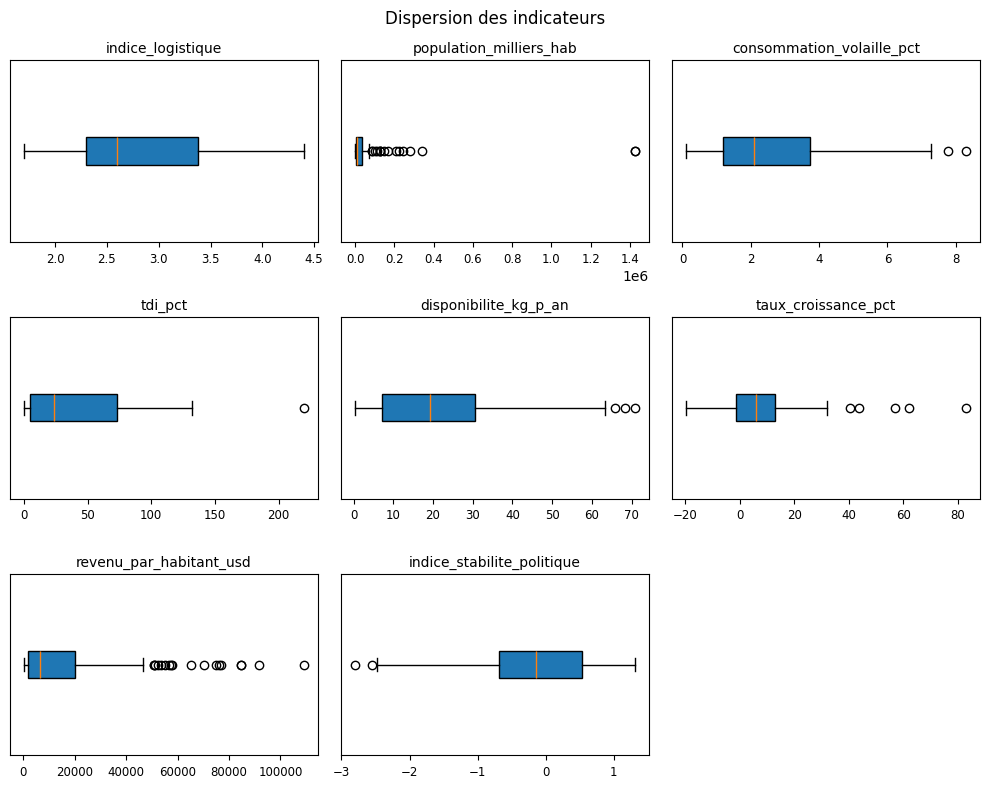

In [176]:
# Trace la dispersion de chaque indicateur

fig, axs = plt.subplots(3, 3, figsize=(10, 8))

for i, indicateur in enumerate(indicateurs):
    r = i // 3
    c = i % 3
    axs[r, c].boxplot(indicateur, data=df_final, patch_artist=True, vert=False)
    axs[r, c].set_title(indicateur, size=10)
    axs[r, c].yaxis.set_major_locator(plt.NullLocator())
    axs[r, c].tick_params(axis='x', which='both', labelsize=8.5)

# Supprime les graphiques vides
[fig.delaxes(ax) for ax in axs.flatten() if not ax.has_data()]

fig.suptitle('Dispersion des indicateurs')

plt.tight_layout()

plt.show()

del fig, axs, i, indicateur, r, c

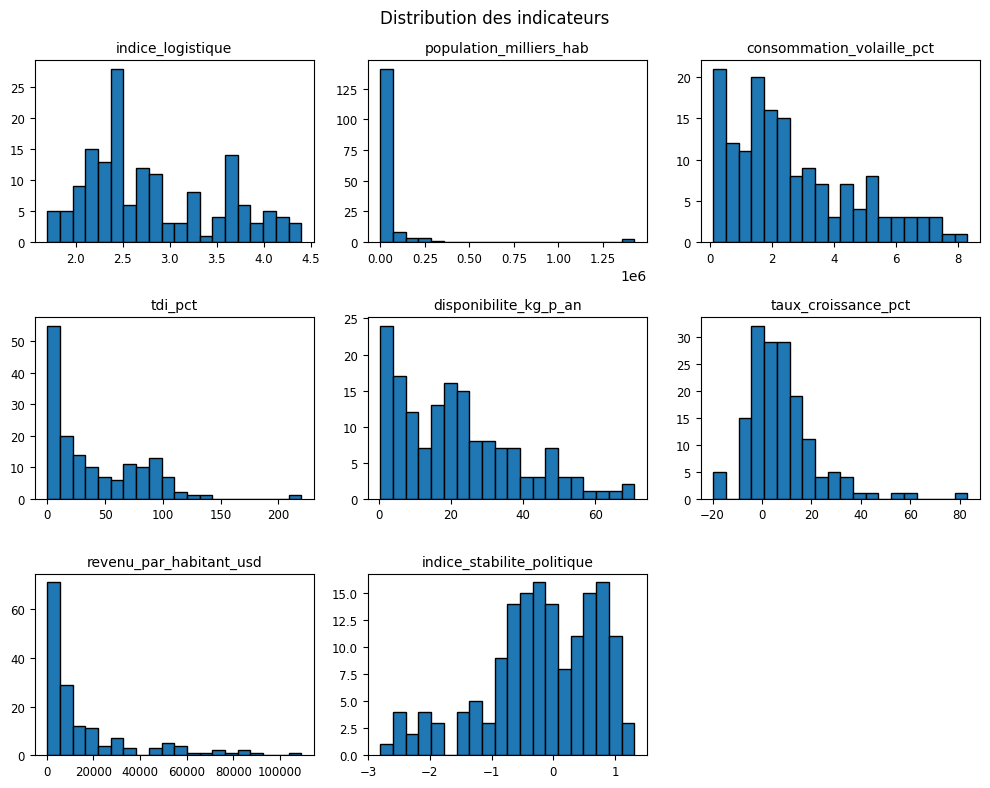

In [177]:
# Trace la distribution des indicateurs

fig, axs = plt.subplots(3, 3, figsize=(10, 8))

for i, indicateur in enumerate(indicateurs):
    r = i // 3
    c = i % 3
    axs[r, c].hist(indicateur, data=df_final, edgecolor='k', bins=20)
    axs[r, c].set_title(indicateur, size=10)
    axs[r, c].tick_params(axis='both', which='both', labelsize=8.5)

# Supprime les graphiques vides
[fig.delaxes(ax) for ax in axs.flatten() if not ax.has_data()]

fig.suptitle('Distribution des indicateurs')

plt.tight_layout()

plt.show()

del fig, axs, i, r, c

En parcourant les visuels ci-dessus, nous remarquons que la dispersion de chaque indicateur n'est pas centrée. 'population_milliers_hab' est très concentrée.  
Les boîtes à moustache nous indique également la présence d'éventuels outliers. Sachant que l'ACP est sensible aux outliers, nous devons investiguer pour  
en savoir plus.  
Nous allons donc afficher les outliers pour chaque indicateur. Cela nous permettra de savoir si nous les conservons ou pas.

Comme nous allons analyser chaque indicateur, nous créons une fonction que nous appliquerons sur chacun.

In [178]:
def display_outliers_tab(indicateur, position=['upper', 'lower']):
    """
    Affiche les pays outliers pour un indicateur donné de df_final.
    Paramètres :
    - indicateur : le nom de l'indicateur à afficher.
    - position : la position des outlier à afficher.
    """

    # Calcul les bornes max/min
    Q1 = df_final[indicateur].quantile(0.25)
    Q3 = df_final[indicateur].quantile(0.75)
    IQR = Q3 - Q1
    max_boxplot = 1.5 * IQR + Q3
    min_boxplot = Q1 - 1.5 * IQR

    # Filtre les outliers
    if position == 'upper':
        return df_final.loc[
            df_final[indicateur] >= max_boxplot, ['pays', indicateur]
        ].sort_values(by=indicateur, ascending=False)
    elif position == 'lower':
        return df_final.loc[
            df_final[indicateur] <= min_boxplot, ['pays', indicateur]
        ].sort_values(by=indicateur)

Nous pouvons maintenant appliquer cette fonction sur chaque indicateur. Nous connaitront ainsi les outliers.

In [179]:
display_outliers_tab('population_milliers_hab', 'upper')

,pays,population_milliers_hab
64,Inde,1425423.212
28,Chine,1425179.569
151,États-Unis,341534.045
63,Indonésie,278830.529
113,Pakistan,243700.667
106,Nigéria,223150.896
21,Brésil,210306.415
14,Bangladesh,169384.897
124,Fédération de Russie,145579.899
91,Mexique,128613.117


Ràs. Les valeurs ne semblent pas aberrantes.

In [180]:
display_outliers_tab('consommation_volaille_pct', 'upper')

,pays,consommation_volaille_pct
102,Malaisie,8.30
6,Antigua-et-Barbuda,7.78


Ràs. Les valeurs ne semblent pas aberrantes.

In [181]:
display_outliers_tab('tdi_pct', 'upper')

,pays,tdi_pct
108,Pays-Bas,219.85


Seuls les Pays-Bas ont un tdi_pct qui pourrait être assimilé outliers. Nous allons donc importer les données des Pays-Bas pour les années 2018 à 2021 pour comparer les résultats.

In [182]:
display_outliers_tab('disponibilite_kg_p_an', 'upper')

,pays,disponibilite_kg_p_an
68,Israël,70.83
6,Antigua-et-Barbuda,68.33
58,Guyana,65.81


Ràs. Les valeurs ne semblent pas aberrantes.

In [183]:
display_outliers_tab('taux_croissance_pct', 'upper')

,pays,taux_croissance_pct
58,Guyana,83.033524
1,Angola,62.082101
138,République arabe syrienne,56.836206
9,Azerbaïdjan,43.584984
5,Arménie,40.599190


Ràs. Les valeurs ne semblent pas aberrantes. Par exemple, la Guyane s'est mise à extraire beaucoup de pétrole.

In [184]:
display_outliers_tab('revenu_par_habitant_usd', 'upper')

,pays,revenu_par_habitant_usd
109,Norvège,109081.979894
26,Suisse,91745.049488
85,Luxembourg,84804.336933
122,Qatar,84568.338448
151,États-Unis,77086.551228
65,Irlande,76118.080848
67,Islande,74914.531669
39,Danemark,70377.331271
7,Australie,65058.904861
137,Suède,58014.983404


Ràs. Les valeurs ne semblent pas aberrantes.

In [185]:
display_outliers_tab('indice_stabilite_politique', 'lower')

,pays,indice_stabilite_politique
138,République arabe syrienne,-2.80
0,Afghanistan,-2.55


Ràs. Les valeurs ne semblent pas aberrantes. Ces 2 pays sont en guerre.

Pour analyser plus précisemment les outliers tdi_pct des Pays-Bas, nous décidons d'importer les données pour les années 2018 à 2021.

In [186]:
# Importation des fichiers csv
df_disponibilite_pays_bas = pd.read_csv('C:/Users/Willkommen/OneDrive/Docs privés/HERVE/FORMATION/DATA_ANALYST_OC/PROJET 11/DATA/DisponibiliteAlimentaire_Pays_Bas.csv', sep=";", encoding='utf-8')

In [187]:
df_disponibilite_pays_bas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            16 non-null     object 
 1   Domaine                 16 non-null     object 
 2   Code zone (ISO3)        16 non-null     object 
 3   Zone                    16 non-null     object 
 4   Code Élément            16 non-null     int64  
 5   Élément                 16 non-null     object 
 6   Code Produit (FAO)      16 non-null     int64  
 7   Produit                 16 non-null     object 
 8   Code année              16 non-null     int64  
 9   Année                   16 non-null     int64  
 10  Unité                   16 non-null     object 
 11  Valeur                  16 non-null     int64  
 12  Symbole                 16 non-null     object 
 13  Description du Symbole  16 non-null     object 
 14  Note                    0 non-null      floa

In [188]:
# Suppression des lignes où la variable élément est égale à "Nourriture"
df_disponibilite_pays_bas = df_disponibilite_pays_bas[df_disponibilite_pays_bas['Élément'] != "Nourriture"]

# Vérification après suppression
print(df_disponibilite_pays_bas.head())


  Code Domaine                      Domaine Code zone (ISO3)  \
0          FBS  Bilans Alimentaires (2010-)              NLD   
1          FBS  Bilans Alimentaires (2010-)              NLD   
2          FBS  Bilans Alimentaires (2010-)              NLD   
4          FBS  Bilans Alimentaires (2010-)              NLD   
5          FBS  Bilans Alimentaires (2010-)              NLD   

                     Zone  Code Élément                  Élément  \
0  Pays-Bas (Royaume des)          5511               Production   
1  Pays-Bas (Royaume des)          5611  Importations - quantité   
2  Pays-Bas (Royaume des)          5911  Exportations - quantité   
4  Pays-Bas (Royaume des)          5511               Production   
5  Pays-Bas (Royaume des)          5611  Importations - quantité   

   Code Produit (FAO)              Produit  Code année  Année   Unité  Valeur  \
0                2734  Viande de Volailles        2018   2018  1000 t    1074   
1                2734  Viande de Volailles  

Nous pouvons maintenant calculer le tdi_pct pour chaque année.

In [189]:
# Étape 1 : Filtrer les données pertinentes pour les calculs
importations = df_disponibilite_pays_bas[df_disponibilite_pays_bas['Élément'] == "Importations - quantité"]
exportations = df_disponibilite_pays_bas[df_disponibilite_pays_bas['Élément'] == "Exportations - quantité"]
production = df_disponibilite_pays_bas[df_disponibilite_pays_bas['Élément'] == "Production"]

# Étape 2 : Renommer la colonne 'Valeur' pour chaque DataFrame
importations = importations[['Code année', 'Zone', 'Valeur']].rename(columns={'Valeur': 'importations'})
exportations = exportations[['Code année', 'Zone', 'Valeur']].rename(columns={'Valeur': 'exportations'})
production = production[['Code année', 'Zone', 'Valeur']].rename(columns={'Valeur': 'production'})

# Étape 3 : Fusionner les DataFrames sur 'Code année' et 'Zone'
df_tdi = importations.merge(exportations, on=['Code année', 'Zone'], how='left') \
                     .merge(production, on=['Code année', 'Zone'], how='left')

# Remplacer les valeurs manquantes par 0 pour les calculs
df_tdi.fillna(0, inplace=True)

# Étape 4 : Calculer la disponibilité intérieure
df_tdi['disponibilite_interieure'] = (
    df_tdi['production'] + df_tdi['importations'] - df_tdi['exportations']
)

# Étape 5 : Calculer le TDI (%)
df_tdi['tdi_pct'] = (df_tdi['importations'] / df_tdi['disponibilite_interieure'] * 100).round(2)

# Étape 6 : Vérification du résultat
print(df_tdi[['Code année', 'Zone', 'tdi_pct']].head())


   Code année                    Zone  tdi_pct
0        2018  Pays-Bas (Royaume des)   247.88
1        2019  Pays-Bas (Royaume des)   383.44
2        2020  Pays-Bas (Royaume des)   265.89
3        2021  Pays-Bas (Royaume des)   225.74


En comparant les résultats, le tdi_pct des Pays-Bas pour l'année 2022 n'est pas aberrant.  

En conclusion, nous décidons de conserver tous les outliers.

Nous pouvons passer maintenant aux analyses bivariées.

# Analyse bivariée (multidimensionnelle)

Nous commençons par les corrélations entre les différents indicateurs.  
Nous décidons d'afficher la matrice de corrélation.

In [190]:
pip install Jinja2


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [191]:
import jinja2
print(jinja2.__version__)


3.1.5


In [192]:
correlation_matrix = df_final.corr(numeric_only=True)
correlation_matrix.style.format('{:.2f}')

,indice_logistique,population_milliers_hab,consommation_volaille_pct,tdi_pct,disponibilite_kg_p_an,taux_croissance_pct,revenu_par_habitant_usd,indice_stabilite_politique
indice_logistique,1.00,0.15,0.28,0.13,0.41,-0.16,0.78,0.55
population_milliers_hab,0.15,1.00,-0.08,-0.21,-0.08,-0.03,-0.04,-0.15
consommation_volaille_pct,0.28,-0.08,1.00,-0.05,0.93,0.16,0.24,0.28
tdi_pct,0.13,-0.21,-0.05,1.00,0.01,0.04,0.18,0.32
disponibilite_kg_p_an,0.41,-0.08,0.93,0.01,1.00,0.20,0.43,0.39
taux_croissance_pct,-0.16,-0.03,0.16,0.04,0.20,1.00,-0.05,-0.09
revenu_par_habitant_usd,0.78,-0.04,0.24,0.18,0.43,-0.05,1.00,0.54
indice_stabilite_politique,0.55,-0.15,0.28,0.32,0.39,-0.09,0.54,1.00


Nous affichons cette matrice dans un heatmap.

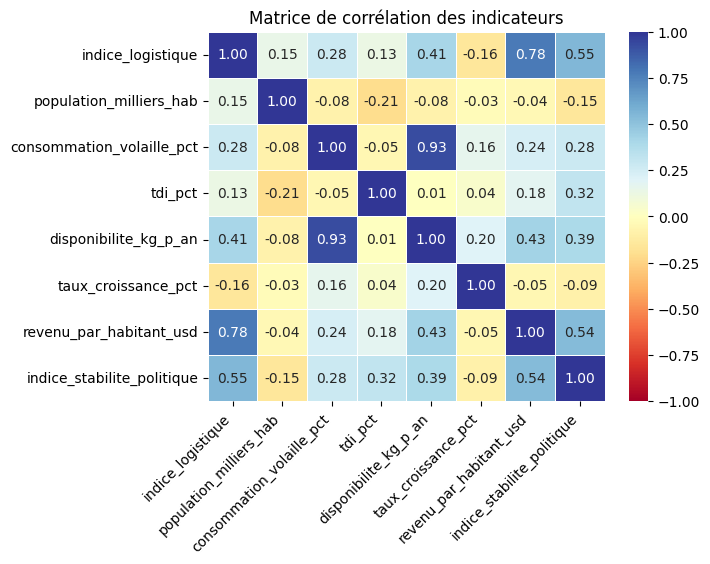

In [193]:
# Trace la matrice
fig, ax = plt.subplots(figsize=(6.4, 4.8))

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', vmin=-1, vmax=1,
annot_kws=None, linewidths=0.6, cmap='RdYlBu', ax=ax)

ax.set_title('Matrice de corrélation des indicateurs')

# Incliner les légendes des x à 45 degrés
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.show()

del fig, ax

Nous remarques que :  
- consommation_volaille_pct et disponibilite_kg_p_an sont très corrélés, suivis de revenu_par_habitant avec indice_logistique  
- indice_logistique, indice_stabilite_politique et revenu_par_habitant_usd sont les indicateurs les plus corrélés avec les autres.

Nous décidons d'afficher les diagrammes de dispersion des indicateurs ayant une corrélation supérieur 0.20 ou -0.20.  
Nous créons une fonction qui nous permettra de ne tracer que les diagrammes des paires d'indicateurs voulus.

In [194]:
def filtered_pairplot(df, corr_value, n_cols=3):
    """
    Trace les paires de variables en les filtrant à partir des coefficients de
    corrélation calculés dans la matrice de corrélation et ajoute une ligne de tendance.
    Paramètres :
    - df : DataFrame source.
    - corr_value : valeur de corrélation minimale pour tracer la paire.
    - n_cols : nombre de colonnes du graphique.
    """

    # Calcule la matrice de corrélation et pivote les colonnes
    df_temp = df.corr(numeric_only=True).unstack().reset_index()

    # Renomme les colonnes
    df_temp = df_temp.rename(
        columns={'level_0': 'var_0', 'level_1': 'var_1', 0: 'value'})
    
    # Sélectionne les lignes ayant une valeur absolue supérieure à 'corr_value'
    df_temp = df_temp.loc[(np.abs(df_temp['value']) >= corr_value)
                          & (np.abs(df_temp['value']) != 1)]
    
    # Supprime les doublons
    df_temp = df_temp.drop_duplicates(subset='value')

    # Détermine le nombre de lignes de graphiques à créer
    n_rows = np.ceil(len(df_temp) / n_cols).astype(int)

    # Trace les graphiques
    fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols,
                            figsize=((n_cols*3), (2*n_rows+2)))
    
    # Boucle sur les lignes du DataFrame
    for i, row in enumerate(df_temp.itertuples()):

        # Calcul la position du graphique
        r = i // n_cols
        c = i % n_cols

        # Ajout du nuage de points avec une ligne de tendance
        sns.regplot(
            x=df[row.var_0],
            y=df[row.var_1],
            scatter_kws={'alpha': 0.6, 'edgecolor': 'w'},
            line_kws={'color': 'red', 'linewidth': 1.5},
            ax=axs[r, c]
        )

        axs[r, c].set_xlabel(row.var_0, size=9)
        axs[r, c].set_ylabel(row.var_1, size=9)
        axs[r, c].tick_params(axis='both', which='both', labelsize=8.5)
    
    # Supprime les graphiques vides
    [fig.delaxes(ax) for ax in axs.flatten() if not ax.has_data()]

    fig.suptitle(
        f'Paires de variables avec coefficient de corrélation ≤ -{corr_value}' 
        f' et ≥ +{corr_value}', 
        y=1.02)
      
    fig.tight_layout()

    plt.show()



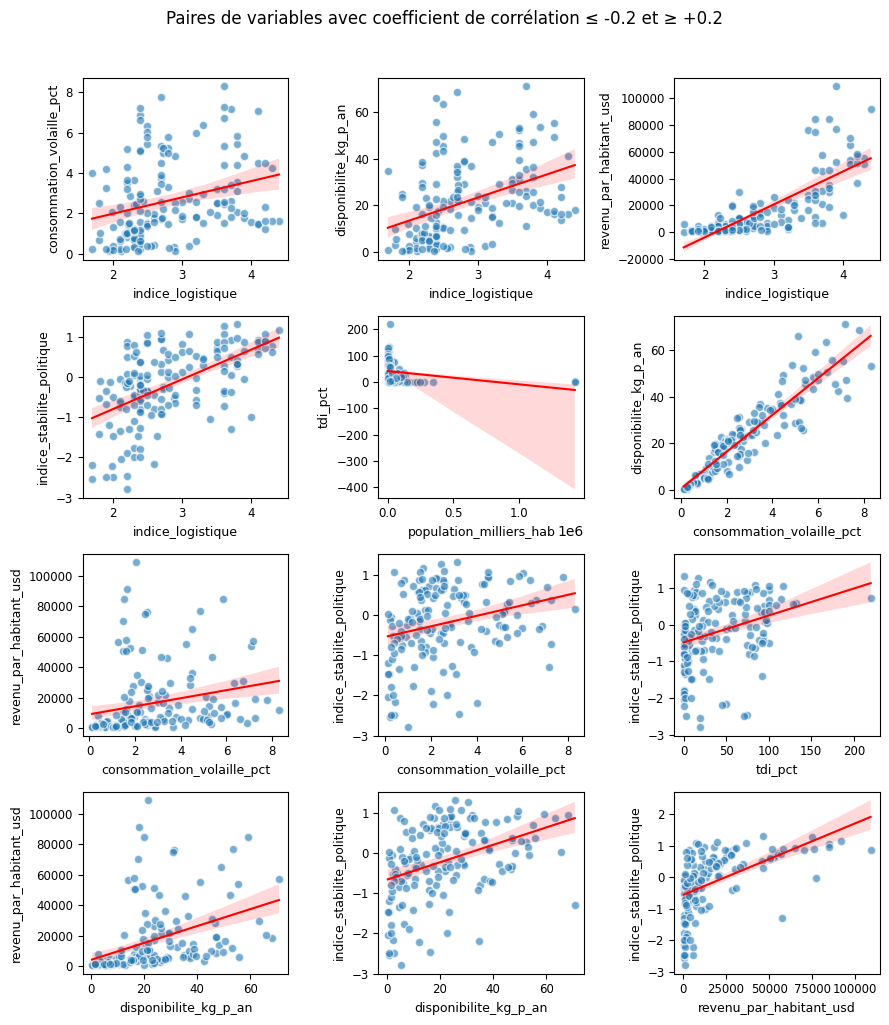

In [195]:
filtered_pairplot(df_final, 0.2)

Eparpiation des points = corrélation peut-être due au hasard

Nous avons terminé nos diverses analyses.  
Nous pouvons procéder à l'exportation de notre df_final au format csv dans le même répertoire que nos données source.

# Exportation des données

In [196]:
df_final.to_csv('C:/Users/Willkommen/OneDrive/Docs privés/HERVE/FORMATION/DATA_ANALYST_OC/PROJET 11/DATA//indicateurs-pays-2022.csv', index=False)